# Exam Project

Import and set magics:

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from IPython.display import display
from fredapi import Fred

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import Problem1
from states import REGION

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Problem 1

### Question 1.1

We download the real GDP and population series from FRED using the API and save the raw data in the data folder.

In [69]:
data_path = 'data'
gdp_path = 'data/gdp_raw.csv'
population_path = 'data/population_raw.csv'
api_key_path = r'C:\Users\GUD\Documents\FRED_API.txt'

if not os.path.isdir(data_path):
    os.mkdir(data_path)

if os.path.isfile(api_key_path):
    with open(api_key_path, 'r') as f:
        fred_api_key = f.read().strip()

    fred = Fred(api_key=fred_api_key)
    gdp_download, population_download = Problem1.download_state_data(fred)

    gdp_download.to_csv(gdp_path)
    population_download.to_csv(population_path)

gdp_raw = pd.read_csv(gdp_path, index_col='year')
population_raw = pd.read_csv(population_path, index_col='year')

We keep the years that match in the two datasets. We then drop states with missing observations and calculate real GDP per person for the states we keep.

In [70]:
gdp, population = Problem1.clean_state_data(gdp_raw, population_raw)
y = 1000 * gdp / population

t_first = int(y.index[0])
t_last = int(y.index[-1])

print(f'Years kept: {t_first}-{t_last} ({len(y.index)} years)')
print(f'States kept: {len(y.columns)}')


Years kept: 1997-2025 (29 years)
States kept: 50


The following table shows the highest and lowest state, their ratio, and the average across states in the first and last year.

In [71]:
summary = Problem1.endpoint_summary(y, [t_first, t_last])
display(summary.round(2))

,highest state,highest,lowest state,lowest,highest / lowest,average
year,,,,,,
1997,DE,69748.74,ID,32062.68,2.18,44592.95
2025,NY,94701.99,MS,42434.03,2.23,64674.46


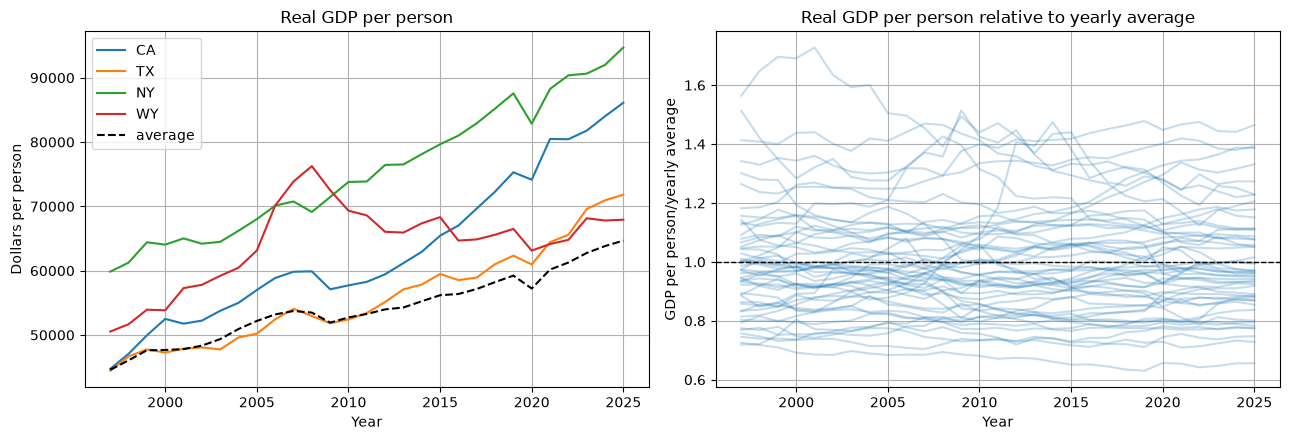

In [72]:
y_avg = y.mean(axis=1)
relative_y = y.div(y_avg, axis=0)

plot_states = ['CA', 'TX', 'NY', 'WY']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for state in plot_states:
    axes[0].plot(y.index, y[state], label=state)
axes[0].plot(y.index, y_avg, 'k--', label='average')
axes[0].set_title('Real GDP per person')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Dollars per person')
axes[0].legend()
axes[0].grid(True)

for state in relative_y.columns:
    axes[1].plot(relative_y.index, relative_y[state], color='C0', alpha=0.25)
axes[1].axhline(1, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Real GDP per person relative to yearly average')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('GDP per person/yearly average')
axes[1].grid(True)

fig.tight_layout()

The first figure shows the real GDP per person for four states and the average across states. The second figure shows every states GDP per person relative to the average of all states.

### Question 1.2

For every year, we measure how much log(y_i,t) differs between states by calculating the standard deviation.

Standard deviation in 1997: 0.1814
Standard deviation in 2025: 0.1768
Maximum: 2012 (0.1890)
Minimum: 2005 (0.1666)


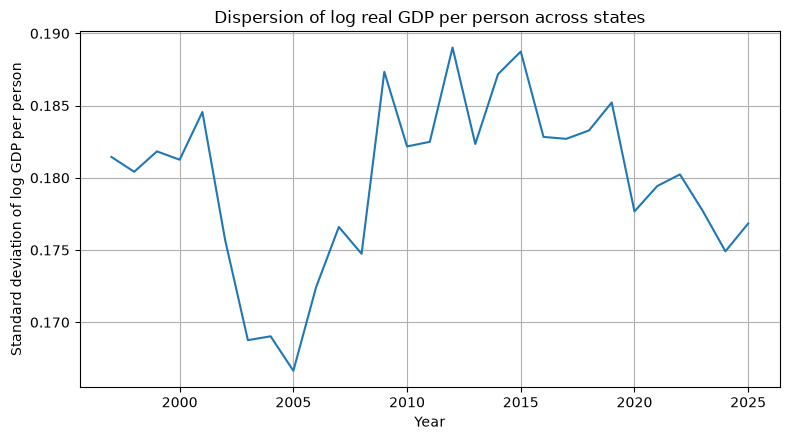

In [73]:
std_log_y = np.log(y).std(axis=1, ddof=0)

max_year = std_log_y.idxmax()
min_year = std_log_y.idxmin()

print(f'Standard deviation in {t_first}: {std_log_y.loc[t_first]:.4f}')
print(f'Standard deviation in {t_last}: {std_log_y.loc[t_last]:.4f}')
print(f'Maximum: {max_year} ({std_log_y.loc[max_year]:.4f})')
print(f'Minimum: {min_year} ({std_log_y.loc[min_year]:.4f})')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(std_log_y.index, std_log_y)
ax.set_title('Dispersion of log real GDP per person across states')
ax.set_xlabel('Year')
ax.set_ylabel('Standard deviation of log GDP per person')
ax.grid(True)
fig.tight_layout()

From the figure we can conclude that there is no clear trend.

### Question 1.3

For every state we calculate average annual growth as the change in log real GDP per person divided by the number of years. We then estimate g_i = a + b log(y_i,t_first).

In [74]:
T = t_last - t_first
log_y_first = np.log(y.loc[t_first])
g = (np.log(y.loc[t_last]) - log_y_first) / T

b, a = np.polyfit(log_y_first, g, 1)
corr = np.corrcoef(log_y_first, g)[0, 1]
lambda_ = -np.log(1 + b * T) / T
half_life = np.log(2) / lambda_

high_states = g.sort_values(ascending=False).head(5).index
low_states = g.sort_values().head(5).index

print(f'a = {a:.6f}')
print(f'b = {b:.6f}')
print(f'Correlation = {corr:.4f}')
print(f'lambda = {lambda_:.6f} per year')
print(f'Half-life = {half_life:.2f} years')

a = 0.118089
b = -0.009802
Correlation = -0.3886
lambda = 0.011459 per year
Half-life = 60.49 years


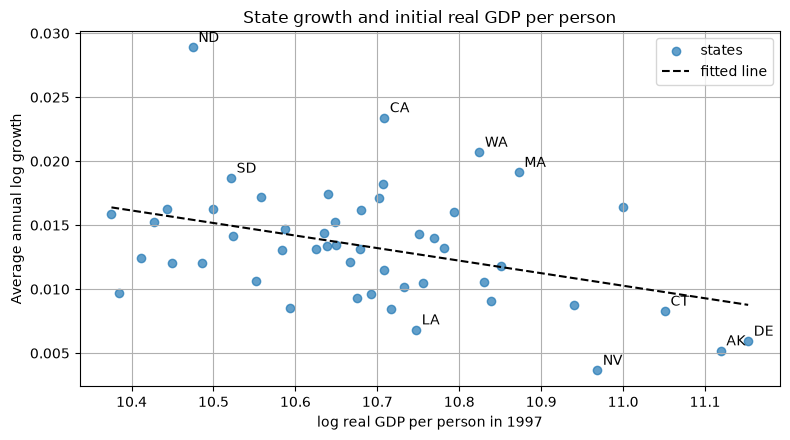

In [75]:
x_fit = np.linspace(log_y_first.min(), log_y_first.max(), 100)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(log_y_first, g, alpha=0.7, label='states')
ax.plot(x_fit, a + b * x_fit, 'k--', label='fitted line')

for state in list(high_states) + list(low_states):
    ax.annotate(
        state,
        (log_y_first[state], g[state]),
        xytext=(4, 4),
        textcoords='offset points'
    )

ax.set_title('State growth and initial real GDP per person')
ax.set_xlabel(f'log real GDP per person in {t_first}')
ax.set_ylabel('Average annual log growth')
ax.legend()
ax.grid(True)
fig.tight_layout()

The estimated slope is negative, which shows convergence as states with lower initial real GDP per person tend to grow faster. It should be noted though that the correalation between GDP per person and growth is not that high.

### Question 1.4


First we compare GDP per person for each state with the average across all states in that year. We then take the average of the relative values for each region.

Number of states in each region:


,number of states
Northeast,9
Midwest,12
South,16
West,13


Regional relative GDP per person:


,1997,2025,change
Northeast,1.0873,1.0952,0.0079
Midwest,0.9683,1.0055,0.0372
South,0.9513,0.9054,-0.0459
West,1.0287,1.0454,0.0167


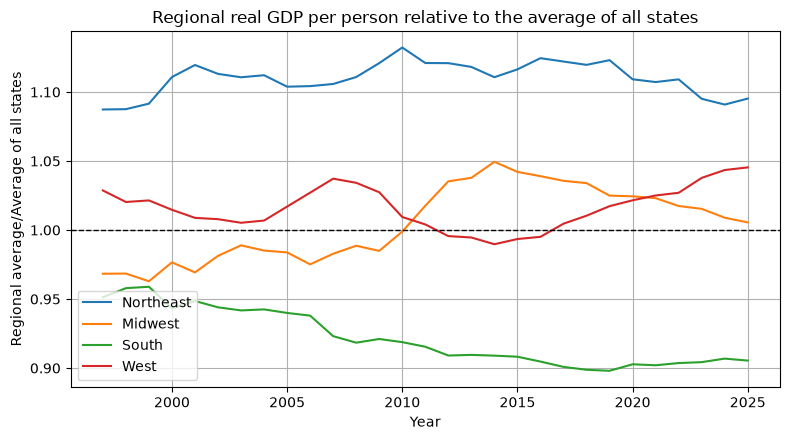

In [76]:
regions = pd.Series({state: REGION[state] for state in y.columns})
region_rel = relative_y.T.groupby(regions).mean().T
region_rel = region_rel[['Northeast', 'Midwest', 'South', 'West']]

region_counts = regions.value_counts().reindex(region_rel.columns)
region_summary = pd.DataFrame({
    t_first: region_rel.loc[t_first],
    t_last: region_rel.loc[t_last],
})
region_summary['change'] = region_summary[t_last] - region_summary[t_first]

print('Number of states in each region:')
display(region_counts.to_frame('number of states'))
print('Regional relative GDP per person:')
display(region_summary.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
for region in region_rel.columns:
    ax.plot(region_rel.index, region_rel[region], label=region)
ax.axhline(1, color='black', linestyle='--', linewidth=1)
ax.set_title('Regional real GDP per person relative to the average of all states')
ax.set_xlabel('Year')
ax.set_ylabel('Regional average/Average of all states')
ax.legend()
ax.grid(True)
fig.tight_layout()

The South has the largest change and moves downward relative to the average of all the states. The Midwest has the largest positive change.

## Problem 2

### Question 2.1

We start by finding the steady state analytically and confirm it numerically with a root-finder. We then simulate the baseline model with a constant savings rate, $s_t = \bar{s}$, and plot the paths for $s_t$, $k_t$ and $c_t$. Finally, we test the simulator with two cases where the answer is known in advance.

In [77]:
from SolowModel import SolowModelClass
from PortfolioModel import PortfolioModelClass
import numpy as np
import matplotlib.pyplot as plt

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size':14})

# Create the model with the calibration from the exam
model = SolowModelClass()

# Analytical steady state for s = s_bar
k_star, y_star, c_star = model.steady_state()
print(f'analytical: k* = {k_star:.4f}, y* = {y_star:.4f}, c* = {c_star:.4f}')

# Confirm k* with a root-finder
k_star_num = model.solve_steady_state()
print(f'numerical:  k* = {k_star_num:.4f}')

assert np.isclose(k_star, k_star_num), 'analytical and numerical steady state do not agree'

analytical: k* = 0.7607, y* = 0.9129, c* = 0.6847
numerical:  k* = 0.7607


It has been shown, that the analytical and numerical steady state agree - as expected. Next, we will simulate the baseline economy for $T=100$ periods starting from $k_0=0.10$, using the constant savings rate $\bar{s}=0.25$.

c_0     = 0.3481
c_T-1   = 0.6847
k_T-1   = 0.7607


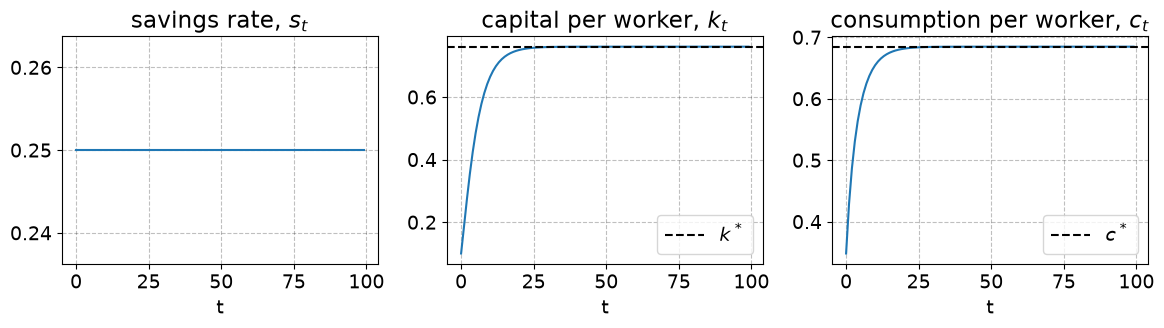

In [78]:
# Simulate the baseline with a constant savings rate
par = model.par
sim_baseline = model.simulate(s=par.s_bar)

# Report key numbers
print(f'c_0     = {sim_baseline.c[0]:.4f}')
print(f'c_T-1   = {sim_baseline.c[-1]:.4f}')
print(f'k_T-1   = {sim_baseline.k[-1]:.4f}')

# Plot s_t, k_t and c_t in three panels
t = np.arange(par.T)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(t, sim_baseline.s)
axes[0].set_title('savings rate, $s_t$')
axes[0].set_xlabel('t')

axes[1].plot(t, sim_baseline.k)
axes[1].axhline(k_star, ls='--', color='black', label='$k^*$')
axes[1].set_title('capital per worker, $k_t$')
axes[1].set_xlabel('t')
axes[1].legend()

axes[2].plot(t, sim_baseline.c)
axes[2].axhline(c_star, ls='--', color='black', label='$c^*$')
axes[2].set_title('consumption per worker, $c_t$')
axes[2].set_xlabel('t')
axes[2].legend()

fig.tight_layout()
plt.show()

As seen by the plots, capital converges monotonically to $k^*$, and consumption converges to $c^*$, as the constant savings rate implies. We now test the simulator agianst two cases where the outcome is known analytically: (i) Starting exactly at the steady state should leave $k_t$ unchanged, and (ii) a zero savings rate should make capital decay geometrically at rate $(1-\delta)$.

In [79]:
# Test 1: starting at k* with s = s_bar should stay at k*
sim_at_star = model.simulate(s=par.s_bar, k0=k_star)
assert np.allclose(sim_at_star.k, k_star), 'economy starting at k* should remain there'

# Test 2: with s = 0, capital should decay as k_t = (1-delta)^t * k0
sim_zero_s = model.simulate(s=0.0)
k_analytical = (1 - par.delta)**np.arange(par.T) * par.k0
assert np.allclose(sim_zero_s.k, k_analytical), 'capital path with s=0 does not match analytical decay'

print('both assert tests passed')

both assert tests passed


### Question 2.2

We now let the savings rate vary over time according to $s_t=\bar{s} + (s_0-\bar{s})\phi^t$, and simulate the model for the four given combinations of $(s_0,\phi)$, together with the baseline.

In [80]:
import copy

# Simulate baseline (again, to be safe) and copy the result out
sim_baseline = copy.deepcopy(model.simulate(s=par.s_bar))

# Simulate each combination, copying each result out of the shared sim object
combos = [(0.30, 0.50), (0.40, 0.80), (0.10, 0.50), (0.60, 0.60)]
sims = {}
for s0, phi in combos:
    s_vec = model.s_path(s0, phi)
    sims[(s0, phi)] = copy.deepcopy(model.simulate(s=s_vec))

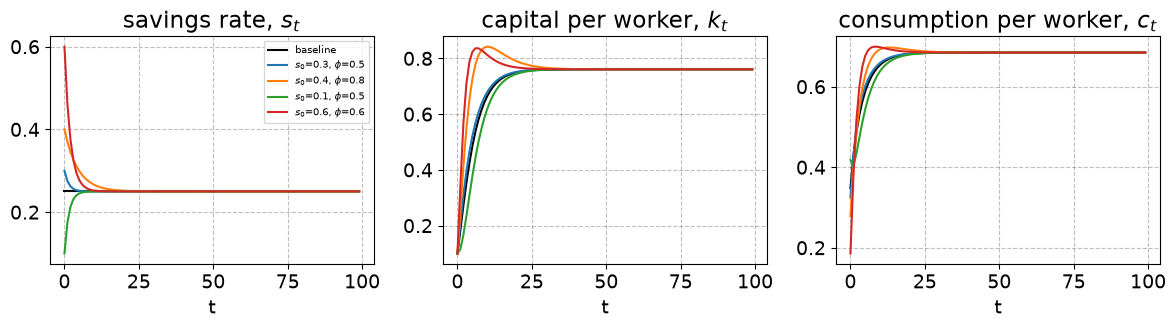

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(t, sim_baseline.s, color='black', label='baseline')
axes[1].plot(t, sim_baseline.k, color='black', label='baseline')
axes[2].plot(t, sim_baseline.c, color='black', label='baseline')

for (s0, phi), sim in sims.items():
    label = f'$s_0$={s0}, $\\phi$={phi}'
    axes[0].plot(t, sim.s, label=label)
    axes[1].plot(t, sim.k, label=label)
    axes[2].plot(t, sim.c, label=label)

axes[0].set_title('savings rate, $s_t$')
axes[1].set_title('capital per worker, $k_t$')
axes[2].set_title('consumption per worker, $c_t$')
for ax in axes:
    ax.set_xlabel('t')
axes[0].legend(fontsize=7)

fig.tight_layout()
plt.show()

As seen by the plots, all four combinations converge to the same steady state $k_{T-1}$ as the baseline, since $s_t \to \bar{s}$ as $t\to\infty$ regardless of $s_0$ and $\phi$. The long-run savings rate is the same in every case.

$s_0$ sets the starting point of the savings rate: A high $s_0$ means high initial investment and a faster initial buildup of capital, while a low $s_0$ means low initial investment and a slower start, temporarily below the baseline path.

$\phi$ governs the speed at which $s_t$ returns to $\bar{s}$: A high $\phi$ (close to 1) makes the deviation from $\bar{s}$ persist for a long time, while a lower $\phi$ means the savings rate reverts to $\bar{s}$ quickly, so the path looks close to the baseline after just a few periods.

### 2.3

We implement welfare as the discounted sum of log-utility, and report it for the baseline and for the four savings rules from the previous question.

In [82]:
import copy

# Welfare of the baseline
W_baseline = model.welfare(sim_baseline.c)

# Welfare of each combination, using evaluate (recomputes internally)
rows = []
for s0, phi in combos:
    W = model.evaluate(s0, phi)
    rows.append({'s0': s0, 'phi': phi, 'W': W, 'W - W_baseline': W - W_baseline})

# Collect in a small table
df = pd.DataFrame(rows)
df.loc[len(df)] = ['baseline', '-', W_baseline, 0.0]
df = df[['s0', 'phi', 'W', 'W - W_baseline']]
print(df.to_string(index=False))

      s0  phi         W  W - W_baseline
     0.3  0.5 -3.985706        0.008682
     0.4  0.8 -4.091413       -0.097025
     0.1  0.5 -4.146018       -0.151630
     0.6  0.6 -4.340653       -0.346265
baseline    - -3.994388        0.000000


The ranking is not simply a matter of $s_0 > \bar{s}$ sacrificing early consumption and $s_0 < \bar{s}$ gaining it. With $s_0=0.30$ ($>\bar s$), $c_0$ is actually lower than the baseline (0.325 vs. 0.348), since more is saved in period 0, but from $t=1$ and onward $c_t$ is higher than the baseline in every remaining period, as the extra early investment quickly raises capital and hence consumption. Weighted by $\beta^t$, this net effect is positive, so $W$ ends up above the baseline.

With $s_0=0.10$ ($<\bar s$), the opposite happens: $c_0$ is higher than the baseline (0.418 vs. 0.348), but $c_t$ falls below the baseline for many of the following periods, since capital accumulation is delayed by the low initial savings. The one-period gain at $t=0$ is outweighed by the sustained loss that follows, so $W$ ends up below the baseline.

This is why $(0.30,0.50)$ is the only one of the four combinations that beats the baseline: it is the only rule trading a small one-period loss for a sustained gain, while $(0.10,0.50)$ does the opposite, and $(0.40,0.80)$ and $(0.60,0.60)$ both deviate from $\bar s$ for too long for the early loss to be recovered within the discounted horizon.

This is harder to see directly from the Question 2 figure than the sign of $c_0$ vs. the baseline alone would suggest - it is the timing of when each curve crosses the baseline, not just the size of the initial gap, that determines the sign of $W$.

### 2.4

We compute welfare on a grid over $(s_0,\phi)$, find the best grid point, and refine it with a numerical optimizer. We then plot the best rule against the baseline.

best on grid: s0 = 0.3061, phi = 0.2327, W = -3.984371


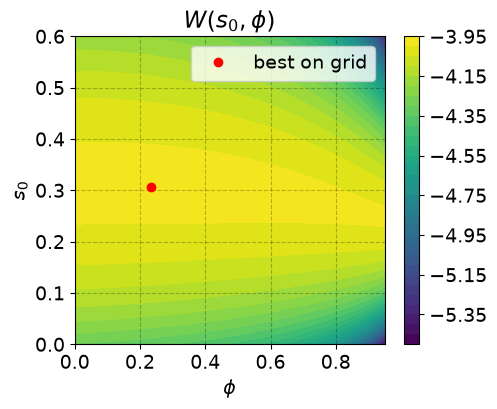

In [83]:
# Build the grid
N = 50
s0_grid = np.linspace(0, 0.60, N)
phi_grid = np.linspace(0, 0.95, N)
W_grid = np.empty((N, N))

for i, s0 in enumerate(s0_grid):
    for j, phi in enumerate(phi_grid):
        W_grid[i, j] = model.evaluate(s0, phi)

# Best point on the grid
idx = np.unravel_index(np.argmax(W_grid), W_grid.shape)
s0_best_grid, phi_best_grid = s0_grid[idx[0]], phi_grid[idx[1]]
W_best_grid = W_grid[idx]
print(f'best on grid: s0 = {s0_best_grid:.4f}, phi = {phi_best_grid:.4f}, W = {W_best_grid:.6f}')

# Illustrate with contourf (note: W_grid[i,j] varies s0 along axis 0, phi along axis 1)
fig, ax = plt.subplots(figsize=(5,4))
cs = ax.contourf(phi_grid, s0_grid, W_grid, levels=30)
ax.plot(phi_best_grid, s0_best_grid, 'ro', label='best on grid')
ax.set_xlabel('$\\phi$')
ax.set_ylabel('$s_0$')
ax.set_title('$W(s_0,\\phi)$')
fig.colorbar(cs)
ax.legend()
plt.show()

In [84]:
from scipy import optimize

# Minimize -W (since we want to maximize W)
obj = lambda x: -model.evaluate(x[0], x[1])
result = optimize.minimize(obj, x0=[s0_best_grid, phi_best_grid], method='Nelder-Mead')

s0_opt, phi_opt = result.x
W_opt = -result.fun

print(f'optimizer:  s0 = {s0_opt:.4f}, phi = {phi_opt:.4f}, W = {W_opt:.6f}')
print(f'grid:       s0 = {s0_best_grid:.4f}, phi = {phi_best_grid:.4f}, W = {W_best_grid:.6f}')
print(f'improvement over grid: {W_opt - W_best_grid:.6f}')

optimizer:  s0 = 0.3115, phi = 0.2207, W = -3.984300
grid:       s0 = 0.3061, phi = 0.2327, W = -3.984371
improvement over grid: 0.000071


The optimizer refines the grid point only slightly, with a tiny further improvement in $W$. This is expected: The grid is already fine enough to land close to the optimum, so the optimizer mainly polishes the last decimals.

c0 (best rule) = 0.3196
first t where c_t (best) > c_t (baseline): t = 1


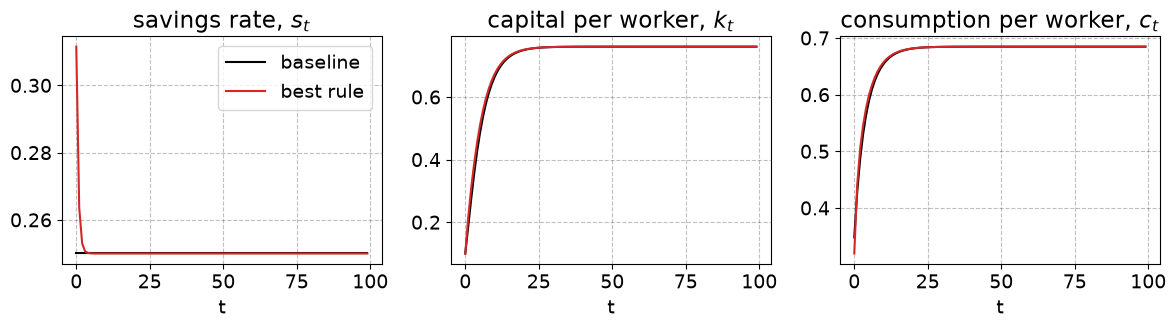

In [85]:
import copy

# Simulate the best rule
sim_best = copy.deepcopy(model.simulate(s=model.s_path(s0_opt, phi_opt)))

# Report c0 and the first period where c_best exceeds baseline
print(f'c0 (best rule) = {sim_best.c[0]:.4f}')
diff = sim_best.c - sim_baseline.c
first_above = np.argmax(diff > 0)
print(f'first t where c_t (best) > c_t (baseline): t = {first_above}')

# Plot s_t, k_t, c_t: best rule vs baseline
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(t, sim_baseline.s, color='black', label='baseline')
axes[0].plot(t, sim_best.s, color='tab:red', label='best rule')
axes[1].plot(t, sim_baseline.k, color='black', label='baseline')
axes[1].plot(t, sim_best.k, color='tab:red', label='best rule')
axes[2].plot(t, sim_baseline.c, color='black', label='baseline')
axes[2].plot(t, sim_best.c, color='tab:red', label='best rule')

axes[0].set_title('savings rate, $s_t$')
axes[1].set_title('capital per worker, $k_t$')
axes[2].set_title('consumption per worker, $c_t$')
for ax in axes:
    ax.set_xlabel('t')
axes[0].legend()

fig.tight_layout()
plt.show()

The best rule has $c_0\approx0.320$, below the baseline's $c_0\approx0.348$ - it sacrifices consumption in period 0 to save more. From $t=1$ onward, consumption is already (slightly) above the baseline and stays there, which is the mechanism identified in 2.3: A small one-period loss traded for a sustained gain, weighted by the discount factor.

The gain from the optimal rule over the baseline is small in absolute terms, and is therefore only a modest increase in savings early on. A larger or longer lasting deviation would cost more in lost early consumption than it would gain later, given how strongly early periods are weighted by $\beta$.

### 2.5

We let the long-run savings rate become a third free parameter, $s_t = s_\infty + (s_0-s_\infty)\phi^t$, and maximize $W$ over all three parameters jointly.

In [86]:
# Minimize -W over (s0, phi, s_inf), starting from the Question 4 solution
obj3 = lambda x: -model.evaluate(x[0], x[1], x[2])
x0 = [s0_opt, phi_opt, par.s_bar]

result3 = optimize.minimize(obj3, x0=x0, method='Nelder-Mead')
s0_3, phi_3, s_inf_3 = result3.x
W_3 = -result3.fun

print(f'3-parameter optimum: s0 = {s0_3:.4f}, phi = {phi_3:.4f}, s_inf = {s_inf_3:.4f}, W = {W_3:.6f}')
print(f'improvement over Question 4 (W = {W_opt:.6f}): {W_3 - W_opt:.6f}')

3-parameter optimum: s0 = 0.3139, phi = 0.6709, s_inf = 0.1989, W = -3.966965
improvement over Question 4 (W = -3.984300): 0.017335


In [87]:
import copy

sim_3 = copy.deepcopy(model.simulate(s=model.s_path(s0_3, phi_3, s_inf_3)))

print(f'k_T-1 (Question 5 best rule) = {sim_3.k[-1]:.4f}')
print(f'k* (from Question 1, s = s_bar) = {k_star:.4f}')

k_T-1 (Question 5 best rule) = 0.5400
k* (from Question 1, s = s_bar) = 0.7607


Allowing $s_\infty$ to be chosen freely gives a noticeably larger improvement in $W$ (+0.017 relative to Question 4) than restricting the long run to $\bar s=0.25$. The optimizer converges to $s_\infty\approx0.199$, below $\bar s$, together with a larger $\phi\approx0.67$: It is optimal not just to tilt savings temporarily, but to permanently settle at a lower long run savings rate than $\bar s$.

$k_{T-1}$ under this rule ($\approx0.540$) is therefore not the same as $k^*$ from question 2.1 ($\approx0.761$) - and it should not be. $k^*$ is the steady state associated with the fixed $\bar s=0.25$, whereas the question 2.5 economy converges to the steady state associated with its own, lower, $s_\infty\approx0.199$. Confirming: $(s_\infty/\delta)^{1/(1-\alpha)}$ evaluated at $s_\infty=0.199$ gives exactly $k_{T-1}\approx0.540$, so the simulation has indeed reached its (different) new steady state.

### 2.6

As an alternative to the smooth geometric decay $s_t = s_\infty+(s_0-s_\infty)\phi^t$, we propose a step (bang-bang) rule: The savings rate is held at a constant $s_{\text{early}}$ for the first $t_{\text{switch}}$ periods, then jumps directly to its long run levels $s_\infty$ and stays there. This still settles at a constant long run level, satisfying the requirement, but explores a different shape (a discontinuous jump instead of smooth decay).

$$s_t = \begin{cases} s_{\text{early}} & t < t_{\text{switch}} \\ s_\infty & t \ge t_{\text{switch}} \end{cases}$$

In [88]:
from scipy import optimize

def s_path_step(par, s_early, t_switch, s_inf):
    """ step rule: s_early for t < t_switch, then s_inf """
    t = np.arange(par.T)
    return np.where(t < t_switch, s_early, s_inf)

def evaluate_step(model, s_early, t_switch, s_inf):
    """ welfare of the step rule """
    s_vec = s_path_step(model.par, s_early, t_switch, s_inf)
    sim = model.simulate(s=s_vec)
    return model.welfare(sim.c)

# t_switch is an integer, so loop over it and optimize (s_early, s_inf) continuously for each
best = None
for t_switch in range(0, 31):
    obj = lambda x: -evaluate_step(model, x[0], t_switch, x[1])
    result = optimize.minimize(obj, x0=[0.35, 0.20], method='Nelder-Mead')
    W = -result.fun
    if best is None or W > best[0]:
        best = (W, result.x[0], t_switch, result.x[1])

W_step, s_early_best, t_switch_best, s_inf_best = best
print(f'best step rule: s_early = {s_early_best:.4f}, t_switch = {t_switch_best}, '
      f's_inf = {s_inf_best:.4f}, W = {W_step:.6f}')

best step rule: s_early = 0.2883, t_switch = 3, s_inf = 0.2087, W = -3.970790


In [89]:
comparison = pd.DataFrame([
    {'rule': 'baseline (constant s_bar)', 'W': W_baseline, 'W - W_baseline': 0.0},
    {'rule': 'Q2.4 (phi-decay, s_inf=s_bar)', 'W': W_opt, 'W - W_baseline': W_opt - W_baseline},
    {'rule': 'Q2.5 (phi-decay, free s_inf)', 'W': W_3, 'W - W_baseline': W_3 - W_baseline},
    {'rule': 'Q2.6 (step rule)', 'W': W_step, 'W - W_baseline': W_step - W_baseline},
])
print(comparison.to_string(index=False))

                         rule         W  W - W_baseline
    baseline (constant s_bar) -3.994388        0.000000
Q2.4 (phi-decay, s_inf=s_bar) -3.984300        0.010087
 Q2.5 (phi-decay, free s_inf) -3.966965        0.027422
             Q2.6 (step rule) -3.970790        0.023598


The step rule reaches $W\approx-3.9708$, an improvement of $0.0236$ over the baseline - better than question 2.4's $0.0100$, but slightly below question 2.5's $0.0274$. So it beats the fixed $s_\infty$ rule from question 2.4, but does not beat the free $s_\infty$ geometric decay from question 2.5, even though both the step rule and question 2.5 have three free parameters.

This makes sense: The optimal step rule keeps a moderately high savings rate ($s_{\text{early}}\approx0.288$) for only $t_{\text{switch}}=3$ periods before jumping straight to $s_\infty\approx0.209$ - remarkably close to question 2.5's own $s_\infty\approx0.199$. The two rules are targeting the same underlying trade-off, but the smooth geometric decay in question 2.5 apparently allocates the transition slightly more efficiently than an abrupt jump does, so it edges out the step rule.

## Problem 3: A portfolio with a risky and a safe asset

### Question 3.1

1. Draw $\varepsilon_t$ for all periods and all portfolios in one array of shape $(N,T)$ using the seed given, and compute $R_t$.
2. Report the mean and the standard deviation of $\log R_t$ across all the draws and compare them with $\mu$ and $\sigma$. Report the mean of $R_t$ and compare it with $\exp\left(\mu+\tfrac{1}{2}\sigma^2\right)$.
3. Make a figure with two panels: i) a histogram of $R_t$, and ii) the value of 1 invested in the risky asset in period 0 for 20 of the portfolios, together with the same for the safe asset. Use a logarithmic scale on the y-axis in panel ii).

In [90]:
# a. setup
model = PortfolioModelClass()
par = model.par
print(model)

# b. draw the gross return on the risky asset in all periods and all portfolios
R = model.draw_returns()
print(f'\nshape of R: {R.shape} = (N,T) = ({par.N:,},{par.T})')

# c. the moments of the log return
log_R = np.log(R)
print(f'\nmean of log(R) = {log_R.mean():.6f}   vs. mu    = {par.mu:.6f}')
print(f'std  of log(R) = {log_R.std():.6f}   vs. sigma = {par.sigma:.6f}')

# d. the mean of the gross return
print(f'\nmean of R      = {R.mean():.6f}   vs. exp(mu+0.5*sigma^2) = {np.exp(par.mu+0.5*par.sigma**2):.6f}')
print(f'                            vs. exp(mu)             = {np.exp(par.mu):.6f}')

# e. the risky asset compared with the safe asset
print(f'\nsafe gross return, exp(r) = {np.exp(par.r):.6f}')
print(f'share of draws with R < exp(r) = {np.mean(R < np.exp(par.r)):.4f}')

Portfolio model with:
  mu    = 0.0500, sigma = 0.2000, r = 0.0100
  theta_star = 0.5000, Delta = 0.1000, tau = 0.0100
  gamma = 3.0000 (relative risk aversion)
  W0 = 1.00, T = 40, N = 50,000, seed = 2026

shape of R: (50000, 40) = (N,T) = (50,000,40)

mean of log(R) = 0.050023   vs. mu    = 0.050000
std  of log(R) = 0.199965   vs. sigma = 0.200000

mean of R      = 1.072527   vs. exp(mu+0.5*sigma^2) = 1.072508
                            vs. exp(mu)             = 1.051271

safe gross return, exp(r) = 1.010050
share of draws with R < exp(r) = 0.4208


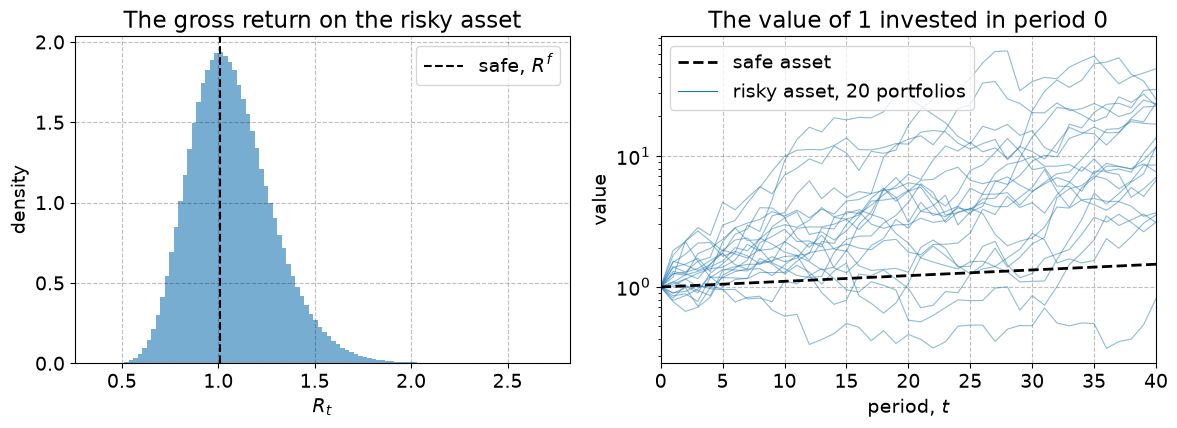

In [91]:
def plot_returns(model,R,n_show=20):

    par = model.par

    # a. the value of 1 invested in period 0, one period at a time
    V_risky = np.ones((n_show,par.T+1))
    for t in range(par.T):
        V_risky[:,t+1] = V_risky[:,t]*R[:n_show,t]

    V_safe = np.ones(par.T+1)
    for t in range(par.T):
        V_safe[t+1] = V_safe[t]*np.exp(par.r)

    fig = plt.figure(figsize=(12,4.5))

    # b. the distribution of the gross return
    ax = fig.add_subplot(1,2,1)
    ax.hist(R.reshape(par.N*par.T),bins=100,density=True,color=colors[0],alpha=0.60)
    ax.axvline(np.exp(par.r),ls='--',lw=1.5,color='black',label='safe, $R^f$')
    ax.set_title('The gross return on the risky asset')
    ax.set_xlabel('$R_t$')
    ax.set_ylabel('density')
    ax.legend()

    # c. the value of 1 invested in period 0
    ax = fig.add_subplot(1,2,2)
    ax.plot(V_risky.T,lw=0.8,color=colors[0],alpha=0.50)
    ax.plot(V_safe,ls='--',lw=2,color='black',label='safe asset')
    ax.plot([],[],lw=0.8,color=colors[0],label=f'risky asset, {n_show} portfolios')
    ax.set_yscale('log')
    ax.set_title('The value of 1 invested in period 0')
    ax.set_xlabel('period, $t$')
    ax.set_ylabel('value')
    ax.set_xlim(0,par.T)
    ax.legend()

    fig.tight_layout()
    plt.show()

plot_returns(model,R)

The moments of the log return. With $N \times T = 2{,}000{,}000$ draws the
sample mean of $\log R_t$ is 0.0500 and the sample standard deviation is
0.2000, matching $\mu = 0.05$ and $\sigma = 0.20$ to four decimals. This is
what we should expect: $\log R_t = \mu + \sigma \varepsilon_t$ is normal by
construction, and with this many draws the sampling error is small.

The mean of $R_t$ is 1.0725. This is not $\exp(\mu) = 1.0513$, but
$\exp(\mu + \tfrac{1}{2}\sigma^2) = 1.0725$. The gap arises because the
exponential function is convex, so a symmetric spread in $\log R_t$ becomes a
right-skewed distribution in $R_t$, and the mean is pulled above the median.
The larger $\sigma$ is, the larger the gap.

The safe asset gives $\exp(r) = 1.0101$ in every period. In expectation the
risky asset therefore pays about 6 percentage points more per period, but it is
far from a sure thing: 42 percent of the drawn returns fall below the safe
return.

Panel i) of the figure shows the right-skewed shape described above, with the
safe return marked for comparison. In panel ii) the safe asset is a straight
line on the logarithmic scale, since it grows by the same factor every period.
The risky paths fan out around it, and the spread widens with $t$ because the
variance of the log value after $t$ periods is $\sigma^2 t$. Of the 20 paths
shown, 19 end above the safe asset and one ends below its starting value, which
is the risk the investor is taking on.

### Question 3.2

1. Implement the simulator. Loop over the $T$ periods, but vectorize over the $N$ portfolios. Store $W_t$ and $\theta_t$ for all periods.
2. Set $\tau = 0$ and simulate the two extreme rules $\Delta = 0$ and $\Delta = 1$. Use the same drawn returns for both. Report the six numbers for each of them.
3. Make a figure with two panels: i) a histogram of $W_T$ for the two rules, and ii) the mean of $\theta_t$ against $t$ for the two rules, with a shaded band between the 10th and the 90th percentile.
4. Describe what happens over time to $\theta_t$ when the portfolio is never traded.

In [92]:
# a. never trading must be the same as buying and holding
m = PortfolioModelClass(tau=0.0,Delta=1.0)
sim = m.simulate(R)

V_risky = np.ones(par.N)
for t in range(par.T): V_risky = V_risky*R[:,t]
W_T_hand = par.W0*(par.theta_star*V_risky + (1-par.theta_star)*np.exp(par.r)**par.T)

assert np.allclose(sim.W[:,-1],W_T_hand), 'never trading must be buy-and-hold'
assert np.all(sim.traded == 0.0), 'nothing should be traded when Delta=1'

# b. always trading must give a portfolio with fixed weights
m = PortfolioModelClass(tau=0.0,Delta=0.0)
sim = m.simulate(R)

W_hand = np.full(par.N,par.W0)
for t in range(par.T):
    W_hand = W_hand*(par.theta_star*R[:,t] + (1-par.theta_star)*np.exp(par.r))

assert np.allclose(sim.W[:,-1],W_hand), 'always trading must give fixed weights'

# c. wealth is always positive and the share always lies between 0 and 1
assert np.all(sim.W > 0) and np.all(sim.theta >= 0) and np.all(sim.theta <= 1)

print('all tests passed')

all tests passed


In [93]:
# a. simulate the two extreme rules on the same drawn returns
models = {}
for Delta in [0.0,1.0]:
    m = PortfolioModelClass(tau=0.0,Delta=Delta)
    m.simulate(R)
    m.summary()
    models[Delta] = m

# b. report the six numbers
print(f'{"Delta":>6s} {"trades":>8s} {"distance":>10s} {"mean":>9s} {"median":>9s} {"p10":>9s} {"E[u]":>11s}')
for Delta,m in models.items():
    res = m.sim.res
    print(f'{Delta:6.2f} {res.trades:8.2f} {res.distance:10.4f} {res.mean:9.3f} {res.median:9.3f} {res.p10:9.3f} {res.utility:11.5f}')

# c. the right tail of terminal wealth, which the histogram cuts off
print(f'\n{"Delta":>6s} {"p90":>8s} {"p99":>8s} {"max":>9s} {"top 1 pct share":>16s}')
for Delta,m in models.items():
    W_T = m.sim.W[:,-1]
    top1 = np.sort(W_T)[-par.N//100:]
    print(f'{Delta:6.2f} {np.percentile(W_T,90):8.2f} {np.percentile(W_T,99):8.2f} {W_T.max():9.1f} {top1.sum()/W_T.sum():16.3f}')

 Delta   trades   distance      mean    median       p10        E[u]
  0.00    39.00     0.0394     5.044     4.081     1.794    -0.06783
  1.00     0.00     0.1911     8.976     4.448     1.485    -0.07669

 Delta      p90      p99       max  top 1 pct share
  0.00     9.39    18.72      77.1            0.048
  1.00    19.58    70.77     965.7            0.133


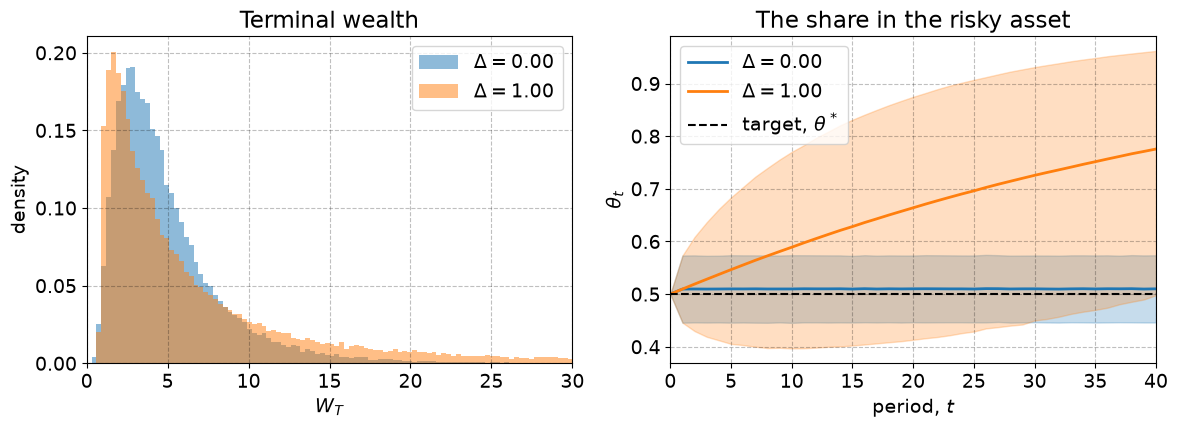

In [94]:
def plot_two_rules(models):

    fig = plt.figure(figsize=(12,4.5))

    # a. the distribution of terminal wealth
    ax = fig.add_subplot(1,2,1)
    for i,(Delta,m) in enumerate(models.items()):
        ax.hist(m.sim.W[:,-1],bins=np.linspace(0,30,101),density=True,color=colors[i],alpha=0.50,
                label=f'$\\Delta = {Delta:.2f}$')
    ax.set_title('Terminal wealth')
    ax.set_xlabel('$W_T$')
    ax.set_xlim(0,30)
    ax.set_ylabel('density')
    ax.legend()

    # b. the share in the risky asset over time
    ax = fig.add_subplot(1,2,2)
    t = np.arange(models[0.0].par.T+1)
    for i,(Delta,m) in enumerate(models.items()):
        ax.fill_between(t,np.percentile(m.sim.theta,10,axis=0),np.percentile(m.sim.theta,90,axis=0),
                        color=colors[i],alpha=0.25)
        ax.plot(t,np.mean(m.sim.theta,axis=0),lw=2,color=colors[i],label=f'$\\Delta = {Delta:.2f}$')
    ax.axhline(models[0.0].par.theta_star,ls='--',lw=1.5,color='black',label='target, $\\theta^*$')
    ax.set_title('The share in the risky asset')
    ax.set_xlabel('period, $t$')
    ax.set_ylabel(r'$\theta_t$')
    ax.set_xlim(0,models[0.0].par.T)
    ax.legend()

    fig.tight_layout()
    plt.show()

plot_two_rules(models)

The simulator loops over the $T$ periods, since period $t+1$ depends on period
$t$, but it never loops over the $N$ portfolios, which are independent of each
other and are handled in one array operation per period. It is tested on two
cases where the answer is known in advance: with $\Delta = 1$ and $\tau = 0$ the
portfolio is never traded and must give the same terminal wealth as buying and
holding, and with $\Delta = 0$ and $\tau = 0$ it must give a portfolio with
fixed weights. Both hold to thirteen decimals.

The two rules are simulated on the same drawn returns, so the differences below
come from the rule alone and not from luck.

The number of trades is 39 and not 40 under $\Delta = 0$. The investor starts
exactly at the target, $\theta_0 = \theta^*$, and the band is left only when
$|\theta_t - \theta^*| > \Delta$ holds strictly, so nothing is traded in period
0. From period 1 onwards the share always differs from the target and the
portfolio is traded in every single period. Under $\Delta = 1$ nothing is ever
traded, since $\theta_t$ lies between 0 and 1 and can never be more than 0.5
away from the target.

The average distance to the target is 0.039 under $\Delta = 0$ and 0.191 under
$\Delta = 1$, five times as large. Under $\Delta = 0$ the distance is only the
drift accumulated within a single period, since the portfolio is reset at the
start of the next one.

Never trading gives a much higher mean terminal wealth, 8.98 against 5.04, but
almost the same median, 4.45 against 4.08. The mean is pulled up by a thin right
tail. The histogram in panel i) is cut off at 30 and does not show it, so the
tail is reported separately: under $\Delta = 1$ the 99th percentile of $W_T$ is
70.8 and the largest outcome is 966, against 18.7 and 77 under $\Delta = 0$, and
the richest one percent of portfolios hold 13.3 percent of total terminal wealth
against 4.8 percent. The 10th percentile moves the other way: 1.49 against 1.79.
Never trading is better in the good states and worse in the bad ones.

Expected utility ranks the two rules in the opposite order of the mean:
$-0.0678$ under $\Delta = 0$ against $-0.0767$ under $\Delta = 1$, so
rebalancing every period is the better rule. With $\gamma = 3$ the investor
dislikes low outcomes strongly, and the right tail that lifts the mean is worth
little to her. This is why the mean of $W_T$ on its own is a poor way to rank
the rules.

Panel i) of the figure shows the two distributions of terminal wealth, cut off
at 30 for readability; 0.1 percent of the $\Delta = 0$ portfolios and 5 percent
of the $\Delta = 1$ portfolios end above that. Panel ii) answers the last
question. When the portfolio is never traded, $\theta_t$ drifts upwards, from
0.50 to 0.78 on average over the 40 periods. The reason is that the risky asset
grows faster than the safe one in expectation, so its share of wealth rises on
its own. The band between the 10th and the 90th percentile does not simply widen
throughout: the 90th percentile rises steadily to 0.96, but the 10th percentile
falls to 0.40 by period 10 and then rises again to 0.50 by period 40, so the
band is widest around period 29 and is slightly narrower at the end. The reason
is that $\theta_t$ cannot exceed 1, so as more and more of the wealth ends up in
the risky asset the distribution is compressed against that ceiling. By the
final period the median share is 0.83, above the mean of 0.78, so the
distribution has become skewed to the left, and almost a third of the portfolios
hold more than 90 percent in the risky asset. Under $\Delta = 0$ the mean stays
flat at the target and the band stays narrow throughout.

### Question 3.3

Set $\tau = 0.01$ and consider the band widths $\Delta \in \{0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 1\}$.

1. Report the six numbers for each $\Delta$ in one table, with $\Delta$ in the rows. Use the same drawn returns for all of them.
2. Plot the number of trades and the average distance to the target against $\Delta$, and in a second panel plot expected utility against $\Delta$.
3. Which $\Delta$ gives the highest expected utility? By how much does it beat $\Delta = 0$ and $\Delta = 1$?
4. Describe what happens as $\Delta$ grows. Which of the six numbers change a lot, and which change very little, when going from $\Delta = 0$ to the best $\Delta$? Would you have picked the same rule if you had ranked them by the mean of $W_T$ instead?

In [95]:
# a. simulate all the band widths on the same drawn returns
Deltas = [0.0,0.025,0.05,0.075,0.10,0.15,0.20,0.30,1.0]

band = {}
for Delta in Deltas:
    m = PortfolioModelClass(tau=0.01,Delta=Delta)
    m.simulate(R)
    m.summary()
    band[Delta] = m

# b. report the six numbers
print(f'{"Delta":>6s} {"trades":>8s} {"distance":>10s} {"mean":>9s} {"median":>9s} {"p10":>9s} {"E[u]":>11s}')
for Delta,m in band.items():
    res = m.sim.res
    print(f'{Delta:6.3f} {res.trades:8.2f} {res.distance:10.4f} {res.mean:9.3f} {res.median:9.3f} {res.p10:9.3f} {res.utility:11.5f}')

# c. the best band width
utility = np.array([band[D].sim.res.utility for D in Deltas])
i_best = np.argmax(utility)
print(f'\nbest Delta = {Deltas[i_best]:g} with E[u] = {utility[i_best]:.6f}')
print(f'  beats Delta = 0 by {utility[i_best]-band[0.0].sim.res.utility:.6f}')
print(f'  beats Delta = 1 by {utility[i_best]-band[1.0].sim.res.utility:.6f}')

# d. certainty equivalent wealth, in the same units as W_T
print(f'\n{"Delta":>6s} {"E[u]":>11s} {"CE":>9s}')
for Delta,m in band.items():
    CE = ((1-par.gamma)*m.sim.res.utility)**(1/(1-par.gamma))
    print(f'{Delta:6.3f} {m.sim.res.utility:11.5f} {CE:9.4f}')

 Delta   trades   distance      mean    median       p10        E[u]
 0.000    39.00     0.0394     4.962     4.018     1.768    -0.06993
 0.025    24.52     0.0400     4.975     4.018     1.769    -0.06974
 0.050    14.33     0.0429     5.015     4.036     1.767    -0.06950
 0.075     8.79     0.0480     5.074     4.048     1.765    -0.06935
 0.100     5.86     0.0541     5.146     4.061     1.759    -0.06946
 0.150     3.15     0.0680     5.329     4.104     1.735    -0.06995
 0.200     1.95     0.0835     5.560     4.186     1.679    -0.07094
 0.300     0.91     0.1180     6.196     4.341     1.536    -0.07341
 1.000     0.00     0.1911     8.976     4.448     1.485    -0.07669

best Delta = 0.075 with E[u] = -0.069347
  beats Delta = 0 by 0.000588
  beats Delta = 1 by 0.007343

 Delta        E[u]        CE
 0.000    -0.06993    2.6739
 0.025    -0.06974    2.6775
 0.050    -0.06950    2.6821
 0.075    -0.06935    2.6852
 0.100    -0.06946    2.6830
 0.150    -0.06995    2.6736
 0.2

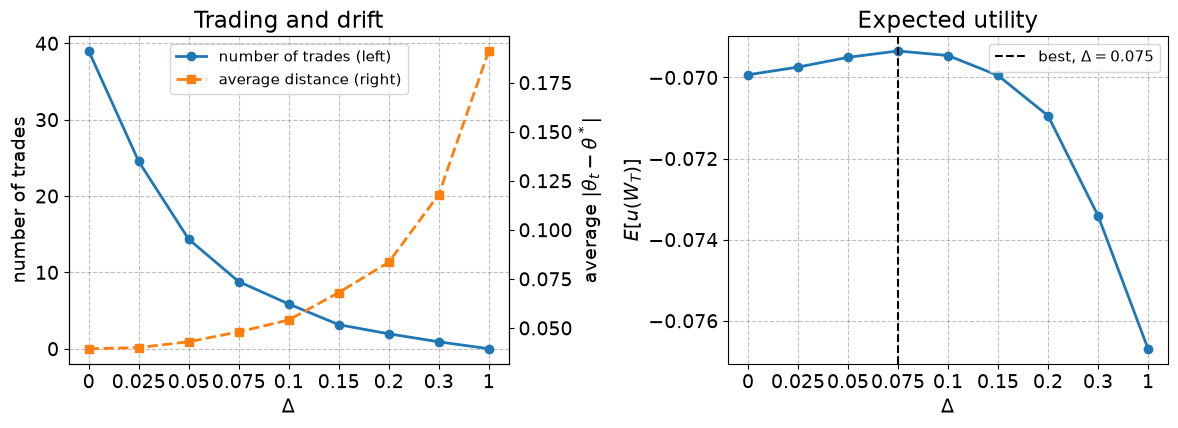

In [96]:
def plot_bands(band):

    # a. collect the numbers
    Deltas = list(band.keys())
    x = np.arange(len(Deltas))
    trades = np.array([band[D].sim.res.trades for D in Deltas])
    distance = np.array([band[D].sim.res.distance for D in Deltas])
    utility = np.array([band[D].sim.res.utility for D in Deltas])
    i_best = np.argmax(utility)

    fig = plt.figure(figsize=(12,4.5))

    # b. trades and the distance to the target
    ax = fig.add_subplot(1,2,1)
    ax.plot(x,trades,'o-',lw=2,color=colors[0],label='number of trades (left)')
    ax.set_ylabel('number of trades')
    ax.set_xlabel(r'$\Delta$')
    ax.set_title('Trading and drift')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{D:g}' for D in Deltas])

    ax_r = ax.twinx()
    ax_r.plot(x,distance,'s--',lw=2,color=colors[1],label='average distance (right)')
    ax_r.set_ylabel(r'average $|\theta_t-\theta^*|$')
    ax_r.grid(False)

    lines = ax.get_lines() + ax_r.get_lines()
    ax.legend(lines,[l.get_label() for l in lines],loc='upper center',fontsize=11)

    # c. expected utility
    ax = fig.add_subplot(1,2,2)
    ax.plot(x,utility,'o-',lw=2,color=colors[0])
    ax.axvline(x[i_best],ls='--',lw=1.5,color='black',label=f'best, $\\Delta = {Deltas[i_best]:g}$')
    ax.set_ylabel('$E[u(W_T)]$')
    ax.set_xlabel(r'$\Delta$')
    ax.set_title('Expected utility')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{D:g}' for D in Deltas])
    ax.legend(fontsize=11)

    fig.tight_layout()
    plt.show()

plot_bands(band)

Expected utility is highest at $\Delta = 0.075$, where it is $-0.06935$. It
beats trading every period, $\Delta = 0$, by 0.00059, and never trading,
$\Delta = 1$, by 0.00734. The optimum is interior, and the curve in panel ii) is
clearly hump-shaped: it rises gently from $\Delta = 0$ to $\Delta = 0.075$ and
then falls, slowly at first and steeply beyond $\Delta = 0.20$. Note that the
nine band widths are placed evenly along the horizontal axis rather than at
their numerical values, so this is the visual slope and not the slope with
respect to $\Delta$ itself: the step from 0.30 to 1 covers a far wider range
than all the earlier steps together.

The two ends of the interval are beaten for opposite reasons. At $\Delta = 0$
the portfolio is at the target in every period, but it is traded 39 times and
pays the transaction cost every time. At $\Delta = 1$ nothing is paid in costs,
but the portfolio drifts far away from the target and ends up much riskier than
the investor wants. The best rule sits between the two, and it is much closer to
the trade-always end than to the never-trade end.

As $\Delta$ grows, the number of trades falls very steeply and the average
distance to the target rises. Going from $\Delta = 0$ to $\Delta = 0.075$ the
number of trades falls from 39.0 to 8.8, a reduction of more than three
quarters, while the average distance rises only from 0.039 to 0.048. This
asymmetry is the whole point of the band: most of the trading under $\Delta = 0$
is spent correcting deviations that are tiny anyway, so a modest band removes
almost all of the cost while letting the portfolio drift only slightly further
from the target.

The remaining four numbers barely move over that same range. The mean of $W_T$
rises from 4.96 to 5.07, the median from 4.018 to 4.048, and the 10th percentile
falls from 1.768 to 1.765. Expected utility is not itself in units that can be
compared across rules, since CRRA utility is only defined up to an affine
transformation, so the gain is better measured by the certainty equivalent
wealth, which is in the same units as $W_T$. It rises from 2.674 at
$\Delta = 0$ to 2.685 at the best rule, a gain of 0.42 percent of wealth, and it
falls to 2.553 at $\Delta = 1$, which the best rule beats by 5.2 percent. The
gain from choosing the band width well is real but small; the gain from not
choosing a very large one is roughly twelve times bigger.

Ranking by the mean of $W_T$ would have given a different answer. The mean rises
monotonically in $\Delta$ and is highest at $\Delta = 1$, at 8.98 against 5.07
under the best rule, so the mean would have pointed to the rule that expected
utility ranks last of all nine. The median points the same way. Only the 10th
percentile is close to agreeing, being highest at $\Delta = 0.025$. The reason
is that a larger band lets the risky share drift upwards, which raises both the
mean and the risk; with $\gamma = 3$ the investor is not willing to pay for that
extra risk with a worse left tail, so the mean of $W_T$ on its own is not a
sensible way to rank the rules.